NAMA : MIA SILVIA YULIATI

NIM : 23424053

KELAS : IF24A

Silakan upload 1 gambar untuk proses konvolusi:


Saving download (7).jpg to download (7).jpg


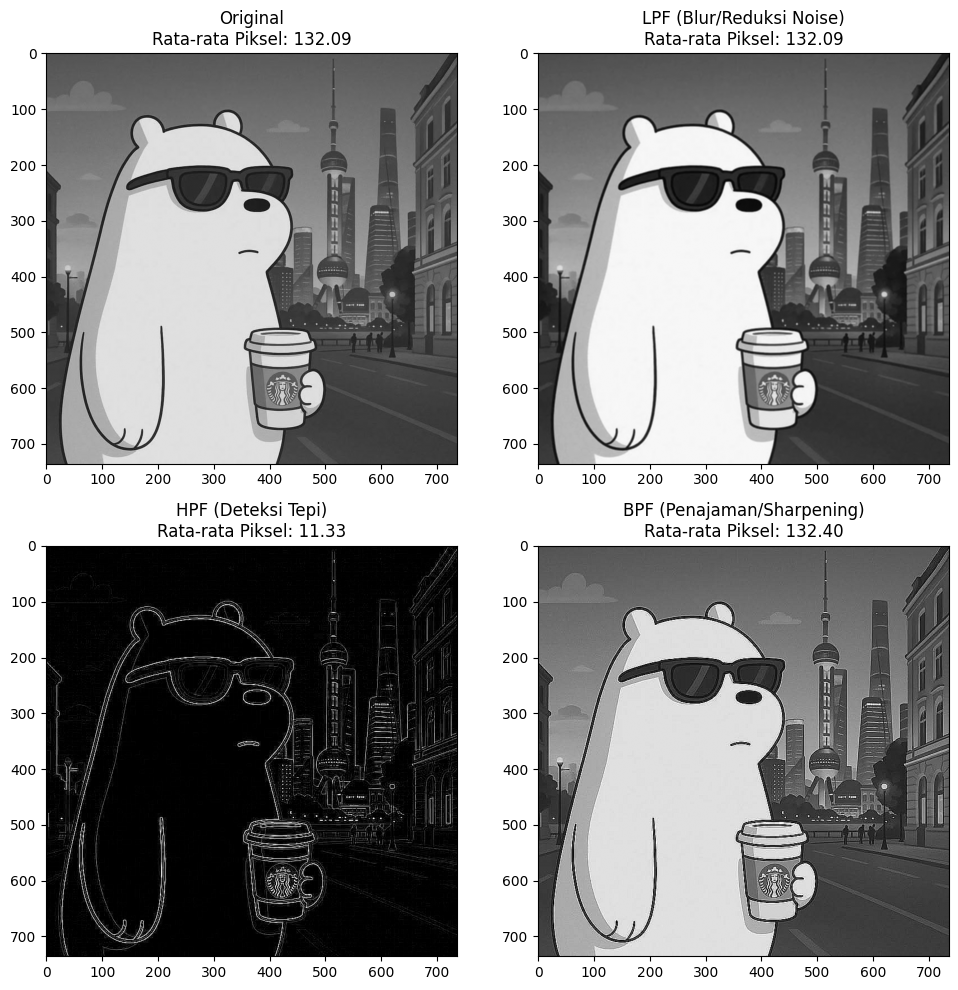

In [1]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Fitur Upload Manual
print("Silakan upload 1 gambar untuk proses konvolusi:")
uploaded = files.upload()

# Mengambil nama file dari gambar yang baru saja diupload
filename = list(uploaded.keys())[0]

# Baca citra grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Gagal membaca gambar. Pastikan format gambar sesuai.")
else:
    # 2. Definisi Kernel
    kernel_lpf = np.ones((3, 3), np.float32) / 9.0
    kernel_hpf = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]], dtype=np.float32)
    kernel_bpf = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

    # 3. Terapkan konvolusi (cv2.filter2D)
    img_lpf = cv2.filter2D(img, -1, kernel_lpf)
    img_hpf = cv2.filter2D(img, -1, kernel_hpf)
    img_bpf = cv2.filter2D(img, -1, kernel_bpf)

    # 4. Tampilkan hasil dan nilai piksel rata-rata
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    axs[0, 0].imshow(img, cmap='gray')
    axs[0, 0].set_title(f'Original\nRata-rata Piksel: {img.mean():.2f}')

    axs[0, 1].imshow(img_lpf, cmap='gray')
    axs[0, 1].set_title(f'LPF (Blur/Reduksi Noise)\nRata-rata Piksel: {img_lpf.mean():.2f}')

    axs[1, 0].imshow(img_hpf, cmap='gray')
    axs[1, 0].set_title(f'HPF (Deteksi Tepi)\nRata-rata Piksel: {img_hpf.mean():.2f}')

    axs[1, 1].imshow(img_bpf, cmap='gray')
    axs[1, 1].set_title(f'BPF (Penajaman/Sharpening)\nRata-rata Piksel: {img_bpf.mean():.2f}')

    plt.tight_layout()
    plt.show()